image resizing


In [1]:
from PIL import Image
image=Image.open("/content/aad.webp")

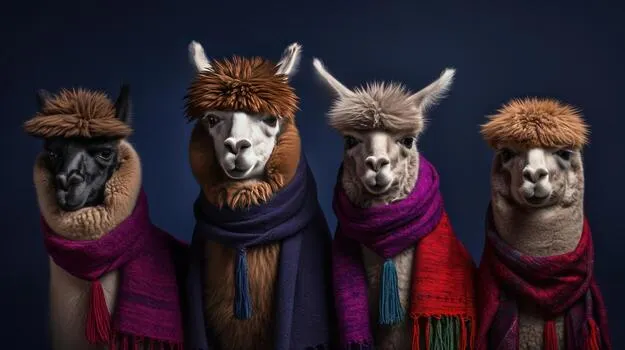

In [3]:
image_resized=image.resize((400,224))
image

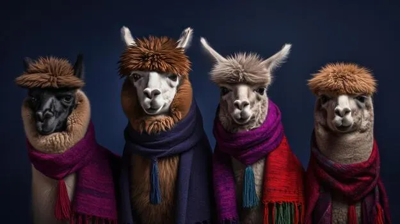

In [4]:
image_resized

image array

array([[[11, 13, 26],
        [11, 13, 26],
        [11, 13, 26],
        ...,
        [17, 23, 39],
        [17, 23, 39],
        [17, 23, 39]],

       [[11, 13, 26],
        [11, 13, 26],
        [11, 13, 26],
        ...,
        [17, 23, 39],
        [17, 23, 39],
        [17, 23, 39]],

       [[11, 13, 26],
        [11, 13, 26],
        [11, 13, 26],
        ...,
        [17, 23, 39],
        [17, 23, 39],
        [17, 23, 39]],

       ...,

       [[ 7, 10, 23],
        [ 7, 10, 23],
        [ 7, 10, 23],
        ...,
        [12, 16, 28],
        [12, 16, 28],
        [12, 17, 26]],

       [[ 7, 10, 23],
        [ 7, 10, 23],
        [ 7, 10, 23],
        ...,
        [12, 16, 28],
        [12, 16, 28],
        [12, 16, 28]],

       [[ 7, 10, 23],
        [ 7, 10, 23],
        [ 7, 10, 23],
        ...,
        [12, 16, 28],
        [12, 16, 28],
        [10, 15, 27]]], dtype=uint8)
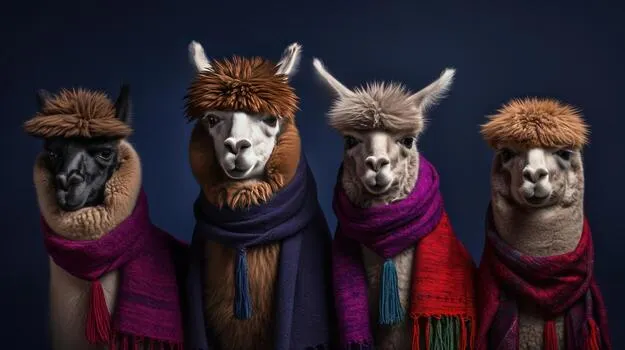

In [5]:
import numpy as np
image_array=np.array(image)
image_array

normalizing

In [6]:

image_array1=np.array(image)/255
image_array1

array([[[0.04313725, 0.05098039, 0.10196078],
        [0.04313725, 0.05098039, 0.10196078],
        [0.04313725, 0.05098039, 0.10196078],
        ...,
        [0.06666667, 0.09019608, 0.15294118],
        [0.06666667, 0.09019608, 0.15294118],
        [0.06666667, 0.09019608, 0.15294118]],

       [[0.04313725, 0.05098039, 0.10196078],
        [0.04313725, 0.05098039, 0.10196078],
        [0.04313725, 0.05098039, 0.10196078],
        ...,
        [0.06666667, 0.09019608, 0.15294118],
        [0.06666667, 0.09019608, 0.15294118],
        [0.06666667, 0.09019608, 0.15294118]],

       [[0.04313725, 0.05098039, 0.10196078],
        [0.04313725, 0.05098039, 0.10196078],
        [0.04313725, 0.05098039, 0.10196078],
        ...,
        [0.06666667, 0.09019608, 0.15294118],
        [0.06666667, 0.09019608, 0.15294118],
        [0.06666667, 0.09019608, 0.15294118]],

       ...,

       [[0.02745098, 0.03921569, 0.09019608],
        [0.02745098, 0.03921569, 0.09019608],
        [0.02745098, 0

colour conversion

array([[17, 17, 17, ..., 27, 27, 27],
       [17, 17, 17, ..., 27, 27, 27],
       [17, 17, 17, ..., 27, 27, 27],
       ...,
       [14, 14, 14, ..., 19, 19, 19],
       [14, 14, 14, ..., 19, 19, 19],
       [14, 14, 14, ..., 19, 19, 18]], dtype=uint8)
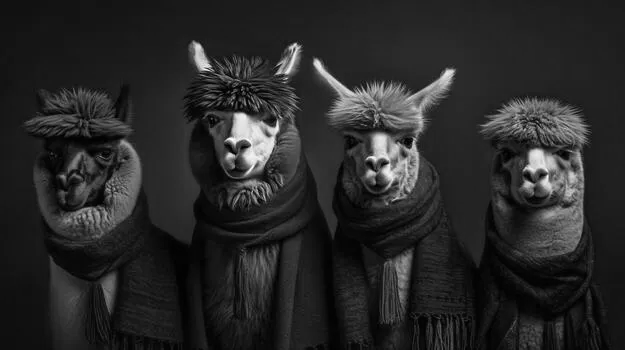

In [8]:
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np=np.array(image)
grayscale_image=cvtColor(image_np,COLOR_BGR2GRAY)
grayscale_image

data augmentation

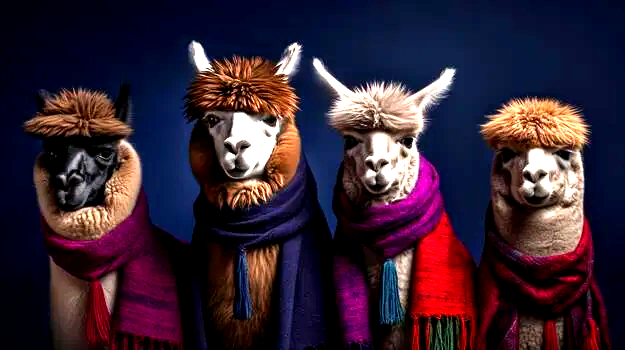

In [20]:
from PIL import Image,ImageEnhance,ImageOps


#flip
flipped=ImageOps.mirror(image)
flipped







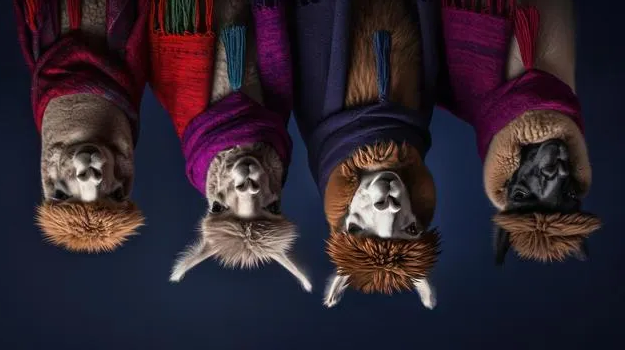

In [21]:
#rorate
rotate=image.rotate(180)
rotate

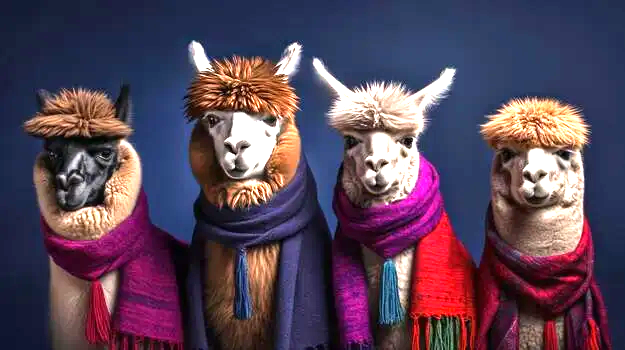

In [22]:
#brightness
enhancer=ImageEnhance.Brightness(image)
brighter=enhancer.enhance(2)
enhancer
brighter

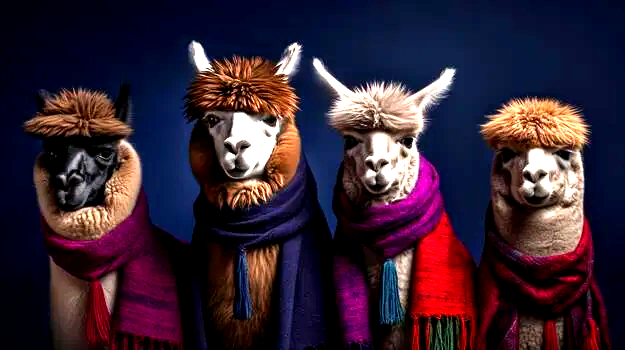

In [23]:
#contrast
contrast=ImageEnhance.Contrast(image).enhance(2)

contrast

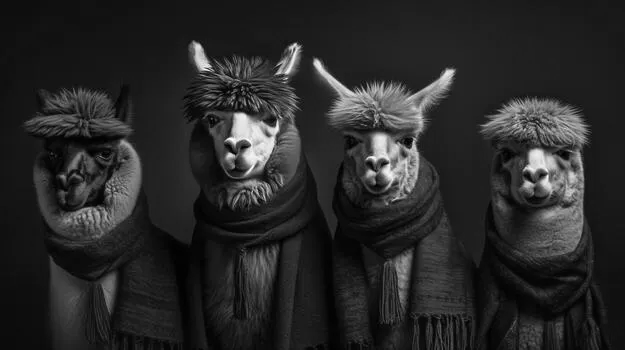

In [24]:
#gray scale

gray=ImageOps.grayscale(image)
gray

In [27]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/aad.webp"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


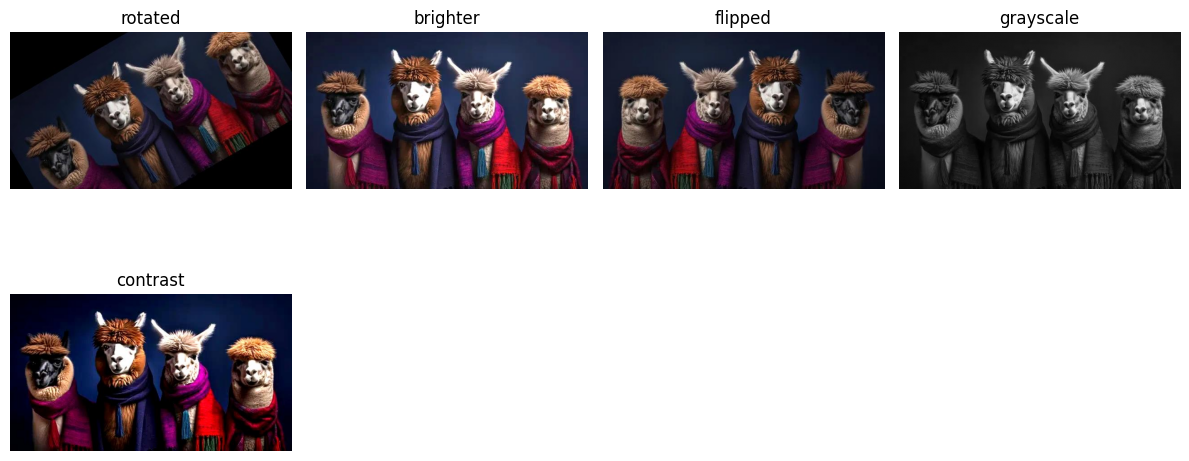

In [29]:
import matplotlib.pyplot as plt

augmented_dir = "augmented_images"
#list all augmented images
augment_images=os.listdir(augmented_dir)

plt.figure(figsize=(12,8))
for i, img_file in enumerate(augment_images):
  img_path=os.path.join(augmented_dir,img_file)
  img=Image.open(img_path)

  plt.subplot(3,4,i+1)
  plt.imshow(img,cmap="gray" if img.mode=="L" else None)
  plt.title(img_file.split('.')[0])
  plt.axis('off')

plt.tight_layout()
plt.show()


